# 03 Delta Hedging the Traded Spread Option

**In this notebook** One delta-hedging experiment: sell the option the backtest
actually trades, the spread option struck at $K_{\text{ATM}}$, and hedge it
in both legs at rebalancing frequencies $\{$none, weekly, daily$\}$. Deltas
come from central finite differences on the Monte Carlo price with common
random numbers, since the $K \neq 0$ option has no closed form.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

TICKERS = ("MO", "PM")
TRADING_DAYS, r_f = 252, 0.04

BETA, ALPHA = 0.735372, 0.302487
KAPPA, THETA = 6.935348, 0.004386
SIGMA_X, SIGMA_STAT = 0.176370, 0.047356
HALF_LIFE_DAYS = 25.1859
MAX_HOLD, T_OPT = 50, 0.198413
Z_ENTRY, Z_EXIT = 2.0, 0.0

SIGMA1, SIGMA2, RHO = 0.209149, 0.194565, 0.560769
S1_0, S2_0 = 40.0410, 94.0219
H_RATIO = 0.313172               # = BETA * S1_0 / S2_0; weight on leg 2

H = H_RATIO
A0 = S1_0                        # leg A = S1
B0 = H * S2_0                    # leg B = h*S2
K_ATM = A0 - B0                  # the traded strike

T = T_OPT
n_steps = MAX_HOLD               # daily steps

rng = np.random.default_rng(3)
plt.rcParams["figure.figsize"] = (10, 5)

print(f"hedging a short spread option: K = K_ATM = {K_ATM:.2f}, "
      f"T = {T:.3f}y, {n_steps} daily steps")

hedging a short spread option: K = K_ATM = 10.60, T = 0.198y, 50 daily steps


# 4. Two-asset delta hedging

The spread option's risk is two-dimensional. Working in the relabeled legs
$A = S_1$, $B = h S_2$ (notebook 02), the deltas are
$\Delta_A = \partial V/\partial A$ and $\Delta_B = \partial V/\partial B$;
in terms of actual shares, hold $\Delta_A$ shares of $S_1$ and
$h\,\Delta_B$ shares of $S_2$ (note $\Delta_B < 0$). For $K \neq 0$ there is
no closed form, so we estimate deltas by **central finite differences on the
Monte Carlo price with common random numbers**:
$$\Delta_A \approx \frac{V(A + \delta,\,B) - V(A - \delta,\,B)}{2\delta}, \qquad \delta \approx 0.01\, A,$$
and symmetrically for $\Delta_B$. Common random numbers (the same simulated
terminal factors in both bumped prices) make the difference quotient nearly
noise-free even with moderate $M$; without them the FD estimator's variance
is $O(1/\delta^2)$ larger.

**Hedge simulation.** Sell one spread option at $t=0$, collect the premium
$V_0$, and rebalance at frequency $\Delta t \in \{\text{daily, weekly, none}\}$:
hold $\Delta_A$ of leg $A$ and $\Delta_B$ of leg $B$, cash earning/paying
rate $r$. Terminal P&L per path, with each step's hedge gain measured in
excess of financing and rolled forward at $r$:
$$\text{P\&L} = V_0 e^{rT}
+ \sum_{k} e^{r(T - t_{k+1})}\Big[\Delta_A(t_k)\big(A(t_{k+1}) - A(t_k)e^{r\Delta t}\big)
+ \Delta_B(t_k)\big(B(t_{k+1}) - B(t_k)e^{r\Delta t}\big)\Big]
- \text{payoff}(T).$$
Each bracketed increment has mean zero under $\mathbb Q$, so every strategy
has expected P&L $\approx 0$; hedging changes the *distribution*, not the
mean. Discrete-hedging theory predicts the hedge-error standard deviation
scales like $\sqrt{\Delta t}$: weekly-to-daily should shrink the std by about
$\sqrt 5 \approx 2.2$.


In [2]:
# Functions from notebook 02 
def _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T):
    sig_hat = np.sqrt(sigma1**2 - 2*rho*sigma1*sigma2 + sigma2**2)
    sqT = sig_hat * np.sqrt(T)
    d1 = (np.log(S1 / S2) + 0.5 * sig_hat**2 * T) / sqT
    return d1, d1 - sqT


def margrabe_price(S1, S2, sigma1, sigma2, rho, T):
    d1, d2 = _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T)
    return S1 * norm.cdf(d1) - S2 * norm.cdf(d2)


def margrabe_deltas(S1, S2, sigma1, sigma2, rho, T):
    d1, d2 = _margrabe_d1_d2(S1, S2, sigma1, sigma2, rho, T)
    return norm.cdf(d1), -norm.cdf(d2)


def simulate_correlated_gbm(S1_0, S2_0, sigma1, sigma2, rho, r, T,
                            n_steps, n_paths, rng):
    dt = T / n_steps
    eps = rng.standard_normal((n_paths, n_steps, 2))
    z1 = eps[:, :, 0]
    z2 = rho * eps[:, :, 0] + np.sqrt(1.0 - rho**2) * eps[:, :, 1]

    def build(S0, sigma, z):
        log_inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z
        logS = np.concatenate([np.full((n_paths, 1), np.log(S0)),
                               np.log(S0) + np.cumsum(log_inc, axis=1)], axis=1)
        return np.exp(logS)

    return build(S1_0, sigma1, z1), build(S2_0, sigma2, z2)


def _cv_adjust(P, C, EC):
    cov = np.cov(P, C, ddof=1)
    var_C = cov[1, 1]
    if var_C < 1e-14:
        return P, 0.0, 0.0
    b_star = cov[0, 1] / var_C
    corr = cov[0, 1] / np.sqrt(cov[0, 0] * var_C) if cov[0, 0] > 0 else 0.0
    return P - b_star * (C - EC), b_star, corr


def mc_spread_option_margrabe_cv(A_T, B_T, K, r, T, margrabe_V):
    P = np.maximum(A_T - B_T - K, 0.0)
    C = np.maximum(A_T - B_T, 0.0)
    P_adj, b_star, corr = _cv_adjust(P, C, np.exp(r * T) * margrabe_V)
    disc = np.exp(-r * T)
    return (disc * P_adj.mean(),
            disc * P_adj.std(ddof=1) / np.sqrt(len(P_adj)), b_star, corr)


In [ ]:
def _terminal_factors(sigma1, sigma2, rho, r, tau, M, rng):
    """Lognormal terminal factors: S_i(tau) = S_i(0) * factor. i.i.d. draws"""
    eps = rng.standard_normal((M, 2))
    z1 = eps[:, 0]
    z2 = rho * eps[:, 0] + np.sqrt(1 - rho**2) * eps[:, 1]
    fA = np.exp((r - 0.5 * sigma1**2) * tau + sigma1 * np.sqrt(tau) * z1)
    fB = np.exp((r - 0.5 * sigma2**2) * tau + sigma2 * np.sqrt(tau) * z2)
    return fA, fB


def mc_deltas_fd_batch(A_vec, B_vec, tau, K, params, h_rel=0.01,
                       M=4_000, seed=0, chunk=4_000):
    """Central-FD MC deltas with common random numbers, for a vector of
    states (A_vec[i], B_vec[i]) at once. Returns (Delta_A, Delta_B)."""
    p = params
    rng = np.random.default_rng(seed)
    fA, fB = _terminal_factors(p["sigma1"], p["sigma2"], p["rho"], p["r"],
                               tau, M, rng)
    disc = np.exp(-p["r"] * tau)
    dA = np.empty_like(A_vec)
    dB = np.empty_like(B_vec)

    for lo in range(0, len(A_vec), chunk):
        sl = slice(lo, lo + chunk)
        a, b = A_vec[sl, None], B_vec[sl, None]
        ha, hb = h_rel * a, h_rel * b

        def price(x, y):                       # (chunk, M) -> (chunk,)
            return disc * np.maximum(x * fA - y * fB - K, 0.0).mean(axis=1)

        dA[sl] = (price(a + ha, b) - price(a - ha, b)) / (2 * ha[:, 0])
        dB[sl] = (price(a, b + hb) - price(a, b - hb)) / (2 * hb[:, 0])
    return dA, dB


def simulate_delta_hedge(A_paths, B_paths, K, params, V0,
                         rebalance_every, delta_fn):
    """Discrete two-asset delta hedge of a SHORT spread option."""
    p = params
    n_paths, n_cols = A_paths.shape
    n_steps = n_cols - 1
    dt = p["T"] / n_steps
    payoff = np.maximum(A_paths[:, -1] - B_paths[:, -1] - K, 0.0)

    pnl = V0 * np.exp(p["r"] * p["T"]) - payoff
    if rebalance_every is None:
        return pnl

    m = rebalance_every
    gains = np.zeros(n_paths)
    for k in range(0, n_steps, m):
        k_next = min(k + m, n_steps)
        tau = p["T"] - k * dt
        dA, dB = delta_fn(A_paths[:, k], B_paths[:, k], tau)
        grow = np.exp(p["r"] * (k_next - k) * dt)
        inc = (dA * (A_paths[:, k_next] - A_paths[:, k] * grow) +
               dB * (B_paths[:, k_next] - B_paths[:, k] * grow))
        gains += inc * np.exp(p["r"] * (p["T"] - k_next * dt))
    return pnl + gains


premium V0(K_ATM) = 1.2875 (SE 0.0007)
deltas at t=0:  FD (true, K=K_ATM): (+0.527, -0.495)   Margrabe proxy (K=0): (+1.000, -1.000)


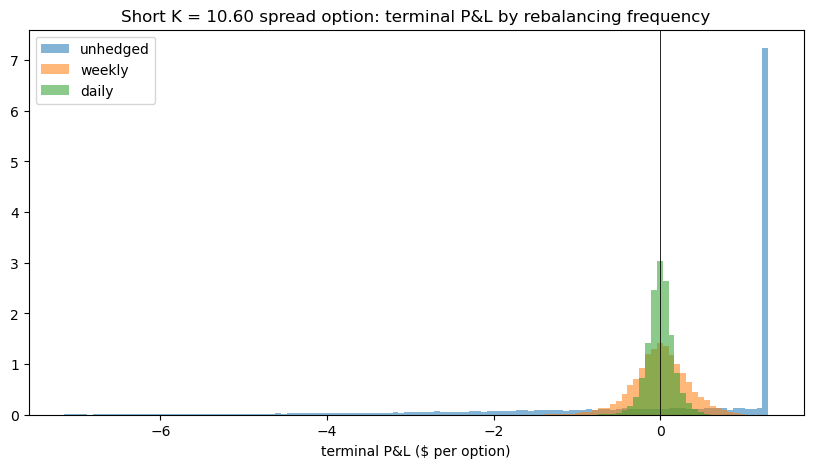

weekly/daily std ratio: 2.15 (theory ~ sqrt(5) = 2.24)


,hedge,mean,std,q05
0,unhedged,-0.0016,1.9291,-4.1640
1,weekly,-0.0034,0.3334,-0.5641
2,daily,0.0008,0.1549,-0.2519


In [5]:
params = dict(sigma1=SIGMA1, sigma2=SIGMA2, rho=RHO, r=r_f, T=T)

# Premium of the traded option via the Margrabe-CV pricer (notebook 02)
rngv = np.random.default_rng(11)
Av, Bv = simulate_correlated_gbm(A0, B0, SIGMA1, SIGMA2, RHO, r_f, T,
                                 1, 2_000_000, rngv)
vm = margrabe_price(A0, B0, SIGMA1, SIGMA2, RHO, T)
V0, V0_se, _, _ = mc_spread_option_margrabe_cv(Av[:, -1], Bv[:, -1],
                                               K_ATM, r_f, T, vm)
print(f"premium V0(K_ATM) = {V0:.4f} (SE {V0_se:.4f})")

# Context: the exact Margrabe (K=0) deltas are a POOR proxy at this strike
dA_fd, dB_fd = mc_deltas_fd_batch(np.array([A0]), np.array([B0]), T, K_ATM,
                                  params, M=400_000, seed=1)
dA_mg, dB_mg = margrabe_deltas(A0, B0, SIGMA1, SIGMA2, RHO, T)
print(f"deltas at t=0:  FD (true, K=K_ATM): ({dA_fd[0]:+.3f}, {dB_fd[0]:+.3f})"
      f"   Margrabe proxy (K=0): ({dA_mg:+.3f}, {dB_mg:+.3f})")

# The experiment: hedge paths + FD deltas at each rebalance date
N_HEDGE = 20_000
Ah, Bh = simulate_correlated_gbm(A0, B0, SIGMA1, SIGMA2, RHO, r_f, T,
                                 n_steps, N_HEDGE, rng)

fd_deltas = lambda a, b, tau: mc_deltas_fd_batch(
    a, b, tau, K_ATM, params, M=4_000, seed=int(tau * 1e6) % 2**31)

rows, pnls = [], {}
for m, name in [(None, "unhedged"), (5, "weekly"), (1, "daily")]:   # ~2 min for daily
    pnl = simulate_delta_hedge(Ah, Bh, K_ATM, params, V0, m, fd_deltas)
    pnls[name] = pnl
    rows.append((name, pnl.mean(), pnl.std(), np.quantile(pnl, 0.05)))
freq_table = pd.DataFrame(rows, columns=["hedge", "mean", "std", "q05"]).round(4)

fig, ax = plt.subplots(figsize=(10, 5))
lo, hi = np.quantile(np.concatenate(list(pnls.values())), [0.002, 0.998])
for name, pnl in pnls.items():
    ax.hist(pnl, bins=120, range=(lo, hi), alpha=0.55, density=True, label=name)
ax.axvline(0, color="k", lw=0.6)
ax.set_xlabel("terminal P&L ($ per option)")
ax.legend()
ax.set_title(f"Short K = {K_ATM:.2f} spread option: "
             "terminal P&L by rebalancing frequency")
plt.show()

print(f"weekly/daily std ratio: "
      f"{pnls['weekly'].std() / pnls['daily'].std():.2f} "
      f"(theory ~ sqrt(5) = {np.sqrt(5):.2f})")
freq_table



- **All three means are ≈ 0**: every hedge increment has zero expectation under $\mathbb Q$ and the option is sold at its model price $V_0 = 1.29$. Hedging reshapes the distribution, not the mean.
- **Unhedged:** the mirrored option payoff, a point mass near $+V_0 e^{rT} \approx 1.30$ where the option expires worthless, and a long left tail (std $1.93$, q05 $-4.16$) where the spread rallies through the strike.
- **Weekly → daily:** std shrinks $1.93 \to 0.333 \to 0.155$; the weekly/daily ratio of $2.15$ matches the discrete-hedging $\sqrt{\Delta t}$ scaling ($\sqrt{5} \approx 2.24$).
- **Deltas:** the true ATM deltas are $(+0.53, -0.50)$ vs. the Margrabe $K=0$ proxy at $(\pm 1)$ — the proxy would hold twice the correctposition in both legs, the same near-linearity that capped the control variate's correlation in notebook 02.

**Limitations.** Deltas and paths come from the *same* GBM model. No transaction costs (which would penalize daily rebalancing); dividends omitted (notebook 02 Sect. 2.1).